# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [ ]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

### Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [ ]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
df_data.shape, df_data.columns

((4324, 9),
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
        'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
       dtype='object'))

In [ ]:
print(df_data.isna().sum())
print('Duplicates:', df_data.duplicated().sum())

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64
Duplicates: 0


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [ ]:
df_data = df_data.drop(columns=['Unnamed: 0.1','Unnamed: 0'])
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Organisation    4324 non-null   object
 1   Location        4324 non-null   object
 2   Date            4324 non-null   object
 3   Detail          4324 non-null   object
 4   Rocket_Status   4324 non-null   object
 5   Price           964 non-null    object
 6   Mission_Status  4324 non-null   object
dtypes: object(7)
memory usage: 236.6+ KB


## Descriptive Statistics

In [ ]:
df_data.describe(include='all')

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964,4324
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Tue Aug 28, 1990 09:05 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3879


In [ ]:
df_data['Price'].describe()

,Price
count,964
unique,56
top,450.0
freq,136


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [ ]:
launches_by_org=df_data['Organisation'].value_counts()
launches_by_org.head()

,count
Organisation,
RVSN USSR,1777
Arianespace,279
General Dynamics,251
CASC,251
NASA,203


In [ ]:
px.bar(launches_by_org, x=launches_by_org.index, y=launches_by_org.values)

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [ ]:
df_data['Rocket_Status'].value_counts()

,count
Rocket_Status,
StatusRetired,3534
StatusActive,790


In [ ]:
px.pie(values=df_data['Rocket_Status'].value_counts().values,names=df_data['Rocket_Status'].value_counts().index)

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
df_data['Mission_Status'].value_counts()

,count
Mission_Status,
Success,3879
Failure,339
Partial Failure,102
Prelaunch Failure,4


In [ ]:
px.pie(values=df_data['Mission_Status'].value_counts().values,names=df_data['Mission_Status'].value_counts().index)

# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [ ]:
price_data=df_data['Price'].dropna()

In [ ]:
px.histogram(price_data,x='Price' if hasattr(price_data,'columns') else price_data, nbins=30)

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
from iso3166 import countries
def get_country(loc):
    c=loc.split(',')[-1].strip()
    mapping={'Russia':'Russian Federation','New Mexico':'USA','Yellow Sea':'China','Shahrud Missile Test Site':'Iran','Pacific Missile Range Facility':'USA','Barents Sea':'Russian Federation','Gran Canaria':'USA'}
    return mapping.get(c,c)
df_data['Country']=df_data['Location'].apply(get_country)


In [ ]:
country_launches=df_data['Country'].value_counts().reset_index(); country_launches.columns=['Country','Launches']

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
failures=df_data[df_data['Mission_Status']!='Success']['Country'].value_counts().reset_index(); failures.columns=['Country','Failures']

In [ ]:
failures.head()

,Country,Failures
0,USA,163
1,Kazakhstan,93
2,Russian Federation,93
3,China,25
4,France,18


# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [ ]:
sun=df_data.groupby(['Country','Organisation','Mission_Status']).size().reset_index(name='count')

In [ ]:
px.sunburst(sun,path=['Country','Organisation','Mission_Status'],values='count')

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [ ]:
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')

org_spend = (
    df_data.groupby('Organisation')['Price']
    .sum()
    .sort_values(ascending=False)
)



In [ ]:
org_spend.head()

,Price
Organisation,
NASA,"61,200.00"
Arianespace,"16,345.00"
ULA,"14,798.00"
CASC,"6,340.26"
SpaceX,"5,444.00"


In [ ]:
px.bar(
    x=org_spend.index,
    y=org_spend.values,
    labels={'x': 'Organisation', 'y': 'Total Cost (Million USD)'}
)

# Analyse the Amount of Money Spent by Organisation per Launch

In [ ]:
org_avg=df_data.groupby('Organisation')['Price'].mean().sort_values(ascending=False)

In [ ]:
org_avg.head()

,Price
Organisation,
NASA,450.00
Boeing,177.29
Arianespace,170.26
ULA,151.00
ILS,101.54


In [ ]:
px.bar(org_avg)

# Chart the Number of Launches per Year

In [ ]:
df_data['Date'] = pd.to_datetime(df_data['Date'], errors='coerce')
launches_year=df_data.groupby(df_data['Date'].dt.year).size()

In [ ]:
px.line(launches_year)

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [ ]:
monthly=df_data.set_index('Date').resample('ME').size().to_frame('launches'); monthly['roll']=monthly['launches'].rolling(12).mean()

In [ ]:
monthly.tail()

,launches,roll
Date,,
2020-04-30 00:00:00+00:00,5,9.08
2020-05-31 00:00:00+00:00,9,9.08
2020-06-30 00:00:00+00:00,7,9.08
2020-07-31 00:00:00+00:00,14,9.33
2020-08-31 00:00:00+00:00,3,8.67


# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [ ]:
df_data['Month']=df_data['Date'].dt.month_name(); df_data['Month'].value_counts()

,count
Month,
December,430
June,386
October,375
April,366
August,358
September,354
March,349
July,347
November,325


In [ ]:
px.bar(df_data['Month'].value_counts())

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [ ]:
avg_price_year=df_data.dropna(subset=['Price']).groupby(df_data['Date'].dt.year)['Price'].mean()

In [ ]:
px.line(avg_price_year)

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [ ]:
top10=df_data['Organisation'].value_counts().head(10).index

In [ ]:
top=df_data[df_data['Organisation'].isin(top10)]

<Axes: xlabel='Date'>

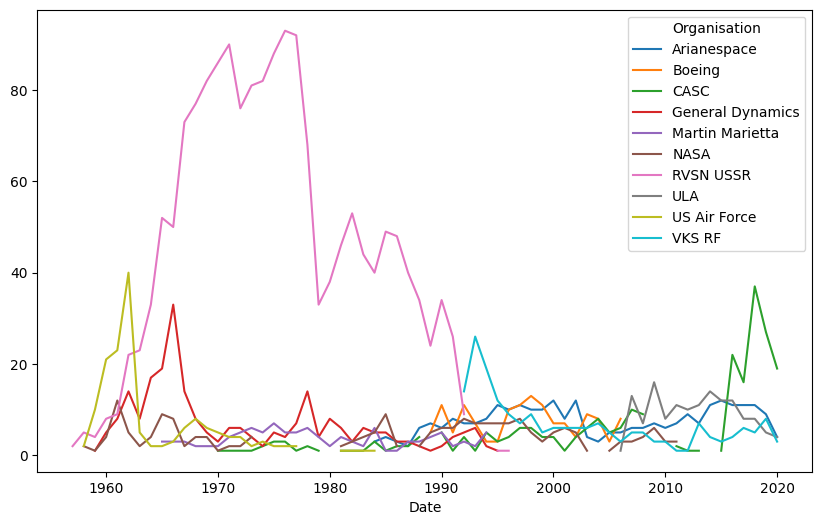

In [ ]:
top.groupby([top['Date'].dt.year,'Organisation']).size().unstack().plot(figsize=(10,6))